## 1. Setup y Configuración

# 4.2 Logit-LASSO para Predicción Direccional de Commodities

## Benchmarks de Literatura Académica

Basado en revisión sistemática de literatura (Tavily + ScholarAI, Dec 2025):

### Métricas Realistas para Predicción Direccional

| Métrica | Rango Típico | Fuente |
|---------|-------------|--------|
| **AUC-ROC** | 0.52 - 0.65 | Wang (2016, Stanford), Ballings et al. (2015) |
| **Accuracy** | 51% - 58% | UV Tilburg (2024), Harvard DASH |
| **F1-Score** | 0.50 - 0.60 | Multiple meta-reviews |

**Nota:** AUC > 0.89 en datos de training es indicativo de **data leakage** o **overfitting severo**.

### Regularización Óptima (C = 1/λ)

| C Óptimo | Contexto | Fuente |
|----------|----------|--------|
| **0.1 - 1.0** | Predicción de precios de acciones | UV Tilburg thesis (2024) |
| **1.0** | Stock direction (L1 penalty) | Forecasting stock prices (Table 4) |
| **0.01 - 0.1** | Feature selection agresiva | Multiple papers |

### Horizonte Temporal

La literatura indica que **horizontes más largos (15-21 días) tienen mejor accuracy** que cortos (1-5 días), debido a menor ruido en la señal.

### Referencias Clave

1. **Wang (2016)** - Stanford CS229: Corn futures direction, 71-80% accuracy en 15-20 días
2. **Ballings et al. (2015)** - European stocks: AUC benchmark con múltiples modelos
3. **Harvard DASH** - LogisticRegression params: penalty='l1', C tuning via CV
4. **Tian (2024)** - Integrating Deep Learning for Commodity Futures: LASSO feature selection
5. **Khalid & Best (2024)** - Comparative analysis: GLM, Ridge, LASSO, Elastic Net

In [1]:
# Imports
import pandas as pd
import numpy as np
from pathlib import Path
import sys
import json
from datetime import datetime
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Sklearn
from sklearn.linear_model import LogisticRegression, LogisticRegressionCV
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import (
    TimeSeriesSplit, 
    GridSearchCV, 
    cross_val_score,
    cross_val_predict
)
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix, classification_report,
    precision_recall_curve, average_precision_score, brier_score_loss,
    log_loss
)
from sklearn.calibration import calibration_curve

from tqdm.auto import tqdm
import warnings
warnings.filterwarnings('ignore')

# Path setup
BASE_DIR = Path.cwd().parents[1]
sys.path.append(str(BASE_DIR / 'src'))

from config import PROCESSED_DIR, logger

# Display settings
pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 1000)

# Configuración
TARGET_COMMODITIES = ['Corn', 'Soybeans', 'Wheat']
HORIZONS = {
    't1': 1,    # 1 día
    't5': 5,    # 1 semana (5 días hábiles)
    't21': 21   # 1 mes (21 días hábiles)
}
RANDOM_STATE = 42

# Directorio de datos finales
FINAL_DIR = PROCESSED_DIR / 'final_modeling'

print(f"✓ Base directory: {BASE_DIR}")
print(f"✓ Commodities: {TARGET_COMMODITIES}")
print(f"✓ Horizontes: {HORIZONS}")

✓ Base directory: c:\Users\trico\OneDrive\UBA\Taller de Programacion\TPFinal
✓ Commodities: ['Corn', 'Soybeans', 'Wheat']
✓ Horizontes: {'t1': 1, 't5': 5, 't21': 21}


## 2. Carga de Datos

In [20]:
# Cargar features seleccionadas y datos
# La notebook 4.1 debe haberse ejecutado primero

# Cargar JSON con features seleccionadas
selected_features_path = FINAL_DIR / 'selected_features.json'

if selected_features_path.exists():
    with open(selected_features_path, 'r') as f:
        selected_features = json.load(f)
    print(f"✓ Features seleccionadas cargadas desde {selected_features_path}")
    
    # Mostrar resumen
    for commodity in TARGET_COMMODITIES:
        print(f"\n{commodity}:")
        for h in HORIZONS.keys():
            n_feat = len(selected_features[commodity][h])
            print(f"  {h}: {n_feat} features")
else:
    print("⚠️ Archivo selected_features.json no encontrado.")
    print("   Ejecuta primero 4.1-feature-selection-optimized.ipynb")
    selected_features = None

# Cargar dataset base (con todas las features y targets)
df_base_path = PROCESSED_DIR / 'features_final_modeling.csv'

if df_base_path.exists():
    df = pd.read_csv(df_base_path, parse_dates=['date'])
    print(f"✓ Dataset base cargado: {df.shape}")
    
    # CORRECCIÓN CRÍTICA: Eliminar filas duplicadas por fecha
    # El dataset tiene 3 filas por fecha (una por commodity), lo cual causa:
    # - Balance de targets incorrecto (16% UP en vez de ~50%)
    # - Data leakage (misma fecha en train y test)
    n_before = len(df)
    df = df.drop_duplicates(subset=['date'], keep='first').reset_index(drop=True)
    n_after = len(df)
    print(f"  → Duplicados eliminados: {n_before:,} → {n_after:,} filas ({n_before - n_after:,} removidas)")
else:
    # Fallback a commodities base
    df = pd.read_csv(PROCESSED_DIR / 'commodities_base_consolidated.csv', parse_dates=['date'])
    print(f"\n⚠️ Usando commodities_base_consolidated: {df.shape}")
    
# Crear targets de dirección si no existen
for commodity in TARGET_COMMODITIES:
    for h_name, h_days in HORIZONS.items():
        target_col = f'{commodity}_direction_{h_name}'
        if target_col not in df.columns:
            future_price = df[commodity].shift(-h_days)
            df[target_col] = (future_price > df[commodity]).astype(float)
            print(f"  Target creado: {target_col}")

# Validar balance de targets
print("\nBalance de targets (% dirección UP):")
for commodity in TARGET_COMMODITIES:
    for h_name in HORIZONS.keys():
        target_col = f'{commodity}_direction_{h_name}'
        if target_col in df.columns:
            pct = df[target_col].mean() * 100
            print(f"  {commodity} {h_name}: {pct:.1f}%")

✓ Features seleccionadas cargadas desde C:\Users\trico\OneDrive\UBA\Taller de Programacion\TPFinal\data\processed\final_modeling\selected_features.json

Corn:
  t1: 63 features
  t5: 110 features
  t21: 108 features

Soybeans:
  t1: 54 features
  t5: 110 features
  t21: 106 features

Wheat:
  t1: 61 features
  t5: 112 features
  t21: 108 features
✓ Dataset base cargado: (20173, 3247)
✓ Dataset base cargado: (20173, 3247)
  → Duplicados eliminados: 20,173 → 6,731 filas (13,442 removidas)
  Target creado: Corn_direction_t1
  Target creado: Corn_direction_t5
  Target creado: Corn_direction_t21
  Target creado: Soybeans_direction_t1
  Target creado: Soybeans_direction_t5
  Target creado: Soybeans_direction_t21
  Target creado: Wheat_direction_t1
  Target creado: Wheat_direction_t5
  Target creado: Wheat_direction_t21

Balance de targets (% dirección UP):
  Corn t1: 47.4%
  Corn t5: 50.0%
  Corn t21: 50.8%
  Soybeans t1: 50.0%
  Soybeans t5: 50.4%
  Soybeans t21: 52.0%
  Wheat t1: 46.9%
  W

In [21]:
# Función para preparar datos
def prepare_data(df, commodity, horizon_name, feature_list, split_date='2023-01-01'):
    """
    Prepara datos para entrenamiento de modelo de clasificación.
    Usa las features seleccionadas por el pipeline de 4.1.
    
    Args:
        df: DataFrame con todos los datos
        commodity: 'Corn', 'Soybeans', o 'Wheat'
        horizon_name: 't1', 't5', o 't21'
        feature_list: Lista de features a usar (desde selected_features.json)
        split_date: Fecha de corte train/test
    
    Returns:
        X_train, X_test, y_train, y_test, feature_names, scaler
    """
    target_col = f'{commodity}_direction_{horizon_name}'
    
    # Usar solo las features seleccionadas
    feature_cols = [f for f in feature_list if f in df.columns]
    
    if len(feature_cols) < len(feature_list):
        missing = set(feature_list) - set(feature_cols)
        print(f"  ⚠️ {len(missing)} features faltantes: {list(missing)[:5]}...")
    
    # Split temporal
    train_mask = df['date'] < split_date
    test_mask = df['date'] >= split_date
    
    X_train = df.loc[train_mask, feature_cols].copy()
    X_test = df.loc[test_mask, feature_cols].copy()
    y_train = df.loc[train_mask, target_col].copy()
    y_test = df.loc[test_mask, target_col].copy()
    
    # Remover filas con target NaN (últimas filas por horizonte)
    train_valid = y_train.notna()
    test_valid = y_test.notna()
    
    X_train = X_train[train_valid]
    y_train = y_train[train_valid]
    X_test = X_test[test_valid]
    y_test = y_test[test_valid]
    
    # Limpiar NaN/Inf en features
    X_train.replace([np.inf, -np.inf], np.nan, inplace=True)
    X_test.replace([np.inf, -np.inf], np.nan, inplace=True)
    X_train.fillna(X_train.median(), inplace=True)
    X_test.fillna(X_train.median(), inplace=True)  # Usar mediana de train
    
    # Estandarizar
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    print(f"  Train: {X_train_scaled.shape}, Test: {X_test_scaled.shape}")
    print(f"  Target balance (train): {y_train.mean():.1%} UP")
    
    return X_train_scaled, X_test_scaled, y_train.values, y_test.values, feature_cols, scaler

## 3. Optimización de Hiperparámetros con TimeSeriesCV

Usamos `TimeSeriesSplit` para respetar la estructura temporal de los datos. El parámetro principal a optimizar es **C** (inverso de regularización λ):

- **C pequeño (ej: 0.01)** → Alta regularización → Más coeficientes en cero → Modelo más simple
- **C grande (ej: 100)** → Baja regularización → Más coeficientes no-cero → Mayor flexibilidad

In [22]:
def optimize_logit_lasso(
    X_train, y_train, 
    feature_names,
    n_splits=5,
    random_state=42
):
    """
    Optimiza Logit-LASSO usando TimeSeriesSplit y GridSearchCV.
    
    AJUSTADO según literatura académica (Wang 2016, Harvard DASH, UV Tilburg 2024):
    - Grid de C concentrado en rango óptimo 0.01-1.0
    - Validación de overfitting (train vs CV gap)
    - Penalty L1 para feature selection automática
    
    Returns:
        best_model: Modelo optimizado
        cv_results: Resultados de cross-validation
        optimization_report: Detalles de optimización + diagnosticos
    """
    # ==========================================================================
    # GRID AJUSTADO SEGÚN LITERATURA
    # UV Tilburg thesis (2024): C óptimo ~1.0 para stocks
    # Wang Stanford (2016): C en rango 0.1-1.0 para commodities
    # ==========================================================================
    param_grid = {
        'C': [0.001, 0.005, 0.01, 0.05, 0.1, 0.25, 0.5, 1.0, 2.0, 5.0]
    }
    
    # TimeSeriesSplit para validación cruzada
    tscv = TimeSeriesSplit(n_splits=n_splits)
    
    # Modelo base
    base_model = LogisticRegression(
        penalty='l1',
        solver='saga',
        max_iter=3000,  # Aumentado para convergencia
        random_state=random_state,
        class_weight='balanced',
        warm_start=True,
        tol=1e-4
    )
    
    # GridSearchCV con múltiples métricas
    scoring = {
        'accuracy': 'accuracy',
        'roc_auc': 'roc_auc',
        'f1': 'f1',
        'precision': 'precision',
        'recall': 'recall'
    }
    
    grid_search = GridSearchCV(
        estimator=base_model,
        param_grid=param_grid,
        cv=tscv,
        scoring=scoring,
        refit='roc_auc',  # Optimizar para AUC-ROC
        return_train_score=True,
        n_jobs=-1,
        verbose=0
    )
    
    # Ejecutar búsqueda
    grid_search.fit(X_train, y_train)
    
    # Mejor modelo
    best_model = grid_search.best_estimator_
    best_C = grid_search.best_params_['C']
    best_idx = grid_search.best_index_
    
    # Coeficientes no-cero
    nonzero_mask = np.abs(best_model.coef_[0]) > 1e-10
    nonzero_features = [f for f, m in zip(feature_names, nonzero_mask) if m]
    
    # ==========================================================================
    # DIAGNÓSTICO DE OVERFITTING (crítico para validación)
    # ==========================================================================
    train_auc = grid_search.cv_results_['mean_train_roc_auc'][best_idx]
    cv_auc = grid_search.cv_results_['mean_test_roc_auc'][best_idx]
    overfit_gap = train_auc - cv_auc
    
    # Alertas basadas en literatura
    overfit_warning = ""
    if cv_auc > 0.75:
        overfit_warning = "⚠️ AUC > 0.75 es sospechoso para predicción direccional (benchmark ~0.52-0.65)"
    if overfit_gap > 0.15:
        overfit_warning += f" ⚠️ Gap train-CV = {overfit_gap:.3f} indica overfitting"
    if train_auc > 0.85:
        overfit_warning += " ⚠️ Train AUC > 0.85 sugiere posible data leakage"
    
    # Reporte
    report = {
        'best_C': best_C,
        'best_lambda': 1/best_C,
        'n_features_total': len(feature_names),
        'n_features_nonzero': len(nonzero_features),
        'sparsity_pct': (1 - len(nonzero_features)/len(feature_names)) * 100,
        'cv_scores': {
            'accuracy': grid_search.cv_results_['mean_test_accuracy'][best_idx],
            'roc_auc': cv_auc,
            'f1': grid_search.cv_results_['mean_test_f1'][best_idx],
            'precision': grid_search.cv_results_['mean_test_precision'][best_idx],
            'recall': grid_search.cv_results_['mean_test_recall'][best_idx]
        },
        'train_scores': {
            'roc_auc': train_auc,
            'accuracy': grid_search.cv_results_['mean_train_accuracy'][best_idx]
        },
        'cv_std': {
            'accuracy': grid_search.cv_results_['std_test_accuracy'][best_idx],
            'roc_auc': grid_search.cv_results_['std_test_roc_auc'][best_idx],
            'f1': grid_search.cv_results_['std_test_f1'][best_idx]
        },
        'overfit_diagnostics': {
            'train_auc': train_auc,
            'cv_auc': cv_auc,
            'gap': overfit_gap,
            'warning': overfit_warning
        },
        'nonzero_features': nonzero_features
    }
    
    # Imprimir warning si existe
    if overfit_warning:
        print(f"    {overfit_warning}")
    
    return best_model, grid_search.cv_results_, report

In [23]:
# Ejecutar optimización para cada commodity y horizonte
results = {}
models = {}
scalers = {}

print("="*80)
print("OPTIMIZACIÓN DE LOGIT-LASSO")
print("="*80)

# Verificar que tenemos las features seleccionadas
if selected_features is None:
    raise ValueError("Ejecuta primero 4.1-feature-selection-optimized.ipynb para generar selected_features.json")

for commodity in TARGET_COMMODITIES:
    print(f"\n{'='*60}")
    print(f"COMMODITY: {commodity}")
    print('='*60)
    
    results[commodity] = {}
    models[commodity] = {}
    scalers[commodity] = {}
    
    for horizon_name in HORIZONS.keys():
        print(f"\n[{horizon_name}] Preparando datos...")
        
        # Obtener features seleccionadas para este commodity/horizonte
        feature_list = selected_features[commodity][horizon_name]
        
        # Preparar datos
        X_train, X_test, y_train, y_test, feature_names, scaler = prepare_data(
            df, commodity, horizon_name, feature_list
        )
        
        print(f"[{horizon_name}] Optimizando C con TimeSeriesCV...")
        
        # Optimizar
        best_model, cv_results, report = optimize_logit_lasso(
            X_train, y_train, feature_names,
            n_splits=5,
            random_state=RANDOM_STATE
        )
        
        # Evaluar en test set
        y_pred = best_model.predict(X_test)
        y_prob = best_model.predict_proba(X_test)[:, 1]
        
        test_metrics = {
            'accuracy': accuracy_score(y_test, y_pred),
            'roc_auc': roc_auc_score(y_test, y_prob),
            'precision': precision_score(y_test, y_pred, zero_division=0),
            'recall': recall_score(y_test, y_pred, zero_division=0),
            'f1': f1_score(y_test, y_pred, zero_division=0)
        }
        
        # Guardar resultados
        results[commodity][horizon_name] = {
            'cv_report': report,
            'test_metrics': test_metrics,
            'cv_results': cv_results,
            'feature_names': feature_names,
            'X_test': X_test,
            'y_test': y_test,
            'y_pred': y_pred,
            'y_prob': y_prob
        }
        models[commodity][horizon_name] = best_model
        scalers[commodity][horizon_name] = scaler
        
        print(f"[{horizon_name}] Best C={report['best_C']:.3f} | "
              f"CV AUC={report['cv_scores']['roc_auc']:.3f} | "
              f"Test AUC={test_metrics['roc_auc']:.3f}")

OPTIMIZACIÓN DE LOGIT-LASSO

COMMODITY: Corn

[t1] Preparando datos...
  Train: (5987, 63), Test: (744, 63)
  Target balance (train): 47.4% UP
[t1] Optimizando C con TimeSeriesCV...
[t1] Best C=0.500 | CV AUC=0.501 | Test AUC=0.488

[t5] Preparando datos...
[t1] Best C=0.500 | CV AUC=0.501 | Test AUC=0.488

[t5] Preparando datos...
  Train: (5987, 110), Test: (744, 110)
  Target balance (train): 50.1% UP
[t5] Optimizando C con TimeSeriesCV...
  Train: (5987, 110), Test: (744, 110)
  Target balance (train): 50.1% UP
[t5] Optimizando C con TimeSeriesCV...
     ⚠️ Gap train-CV = 0.243 indica overfitting
[t5] Best C=5.000 | CV AUC=0.515 | Test AUC=0.532

[t21] Preparando datos...
     ⚠️ Gap train-CV = 0.243 indica overfitting
[t5] Best C=5.000 | CV AUC=0.515 | Test AUC=0.532

[t21] Preparando datos...
  Train: (5987, 108), Test: (744, 108)
  Target balance (train): 51.7% UP
[t21] Optimizando C con TimeSeriesCV...
  Train: (5987, 108), Test: (744, 108)
  Target balance (train): 51.7% UP
[t

## 4. Evaluación en Test Set

In [24]:
def evaluate_model(model, X_test, y_test, threshold=0.5):
    """
    Evalúa modelo en test set con múltiples métricas.
    """
    # Predicciones
    y_pred_proba = model.predict_proba(X_test)[:, 1]
    y_pred = (y_pred_proba >= threshold).astype(int)
    
    # Métricas
    metrics = {
        'accuracy': accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred, zero_division=0),
        'recall': recall_score(y_test, y_pred, zero_division=0),
        'f1': f1_score(y_test, y_pred, zero_division=0),
        'roc_auc': roc_auc_score(y_test, y_pred_proba),
        'avg_precision': average_precision_score(y_test, y_pred_proba),
        'brier_score': brier_score_loss(y_test, y_pred_proba),
        'log_loss': log_loss(y_test, y_pred_proba)
    }
    
    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    
    return metrics, cm, y_pred, y_pred_proba

In [25]:
# Evaluar todos los modelos en test
test_results = {}

print("="*80)
print("EVALUACIÓN EN TEST SET")
print("="*80)

for horizon_name in HORIZONS.keys():
    test_results[horizon_name] = {}
    print(f"\n--- Horizonte: {horizon_name} ({HORIZONS[horizon_name]} días) ---")
    
    for commodity in TARGET_COMMODITIES:
        # Corregido: models[commodity][horizon_name]
        if commodity not in models or horizon_name not in models[commodity]:
            print(f"  {commodity}: No hay modelo")
            continue
        
        model = models[commodity][horizon_name]
        res = results[commodity][horizon_name]
        
        metrics, cm, y_pred, y_pred_proba = evaluate_model(
            model, res['X_test'], res['y_test']
        )
        
        test_results[horizon_name][commodity] = {
            'metrics': metrics,
            'confusion_matrix': cm.tolist(),
            'predictions': y_pred,
            'probabilities': y_pred_proba
        }
        
        print(f"\n{commodity}:")
        print(f"  Accuracy: {metrics['accuracy']:.4f}")
        print(f"  AUC-ROC:  {metrics['roc_auc']:.4f}")
        print(f"  F1-Score: {metrics['f1']:.4f}")
        print(f"  Precision: {metrics['precision']:.4f} | Recall: {metrics['recall']:.4f}")

EVALUACIÓN EN TEST SET

--- Horizonte: t1 (1 días) ---

Corn:
  Accuracy: 0.4852
  AUC-ROC:  0.4878
  F1-Score: 0.5369
  Precision: 0.4693 | Recall: 0.6271

Soybeans:
  Accuracy: 0.5148
  AUC-ROC:  0.5000
  F1-Score: 0.0000
  Precision: 0.0000 | Recall: 0.0000

Wheat:
  Accuracy: 0.4691
  AUC-ROC:  0.4902
  F1-Score: 0.6359
  Precision: 0.4694 | Recall: 0.9857

--- Horizonte: t5 (5 días) ---

Corn:
  Accuracy: 0.4906
  AUC-ROC:  0.5322
  F1-Score: 0.6288
  Precision: 0.4893 | Recall: 0.8795

Soybeans:
  Accuracy: 0.5188
  AUC-ROC:  0.4637
  F1-Score: 0.0272
  Precision: 0.3125 | Recall: 0.0142

Wheat:
  Accuracy: 0.5067
  AUC-ROC:  0.5376
  F1-Score: 0.6236
  Precision: 0.4887 | Recall: 0.8612

--- Horizonte: t21 (21 días) ---

Corn:
  Accuracy: 0.5336
  AUC-ROC:  0.6416
  F1-Score: 0.6208
  Precision: 0.4789 | Recall: 0.8820

Soybeans:
  Accuracy: 0.4516
  AUC-ROC:  0.5870
  F1-Score: 0.5984
  Precision: 0.4300 | Recall: 0.9838

Wheat:
  Accuracy: 0.5766
  AUC-ROC:  0.5503
  F1-Score:

In [26]:
# Tabla resumen
summary_rows = []

for commodity in TARGET_COMMODITIES:
    for horizon_name in HORIZONS.keys():
        if horizon_name in test_results and commodity in test_results[horizon_name]:
            m = test_results[horizon_name][commodity]['metrics']
            r = results[commodity][horizon_name]
            cv_report = r['cv_report']
            
            summary_rows.append({
                'Commodity': commodity,
                'Horizon': horizon_name,
                'Days': HORIZONS[horizon_name],
                'Best_C': cv_report['best_C'],
                'N_Features': cv_report['n_features_nonzero'],
                'CV_AUC': cv_report['cv_scores']['roc_auc'],
                'Test_Accuracy': m['accuracy'],
                'Test_AUC': m['roc_auc'],
                'Test_F1': m['f1'],
                'Test_Precision': m['precision'],
                'Test_Recall': m['recall']
            })

df_summary = pd.DataFrame(summary_rows)
print("\n" + "="*100)
print("RESUMEN DE RESULTADOS")
print("="*100)
display(df_summary.round(4))


RESUMEN DE RESULTADOS


,Commodity,Horizon,Days,Best_C,N_Features,CV_AUC,Test_Accuracy,Test_AUC,Test_F1,Test_Precision,Test_Recall
0,Corn,t1,1,0.500,60,0.5013,0.4852,0.4878,0.5369,0.4693,0.6271
1,Corn,t5,5,5.000,109,0.5152,0.4906,0.5322,0.6288,0.4893,0.8795
2,Corn,t21,21,0.100,83,0.5736,0.5336,0.6416,0.6208,0.4789,0.8820
3,Soybeans,t1,1,0.001,0,0.5000,0.5148,0.5000,0.0000,0.0000,0.0000
4,Soybeans,t5,5,1.000,103,0.5233,0.5188,0.4637,0.0272,0.3125,0.0142
5,Soybeans,t21,21,0.250,99,0.5528,0.4516,0.5870,0.5984,0.4300,0.9838
6,Wheat,t1,1,0.010,2,0.5022,0.4691,0.4902,0.6359,0.4694,0.9857
7,Wheat,t5,5,2.000,109,0.5199,0.5067,0.5376,0.6236,0.4887,0.8612
8,Wheat,t21,21,0.005,3,0.5038,0.5766,0.5503,0.4345,0.4727,0.4020


In [27]:
# =============================================================================
# COMPARACIÓN CON BENCHMARKS DE LITERATURA ACADÉMICA
# =============================================================================
print("="*80)
print("COMPARACIÓN CON BENCHMARKS ACADÉMICOS")
print("="*80)

# Benchmarks de literatura (Tavily + ScholarAI search, Dec 2025)
BENCHMARKS = {
    'AUC': {'min': 0.52, 'max': 0.65, 'suspicious': 0.75},
    'Accuracy': {'min': 0.51, 'max': 0.58, 'suspicious': 0.70},
    'sources': [
        'Wang (2016) Stanford CS229 - Corn futures',
        'Ballings et al. (2015) - European stocks benchmark',
        'UV Tilburg thesis (2024) - Stock price forecasting',
        'Harvard DASH - Financial Market Forecasting'
    ]
}

print("\n📊 BENCHMARKS DE LITERATURA:")
print(f"   AUC-ROC esperado: {BENCHMARKS['AUC']['min']:.2f} - {BENCHMARKS['AUC']['max']:.2f}")
print(f"   Accuracy esperada: {BENCHMARKS['Accuracy']['min']:.2f} - {BENCHMARKS['Accuracy']['max']:.2f}")
print(f"   ⚠️ AUC > {BENCHMARKS['AUC']['suspicious']:.2f} es sospechoso de overfitting/leakage")

print("\n📈 RESULTADOS OBTENIDOS vs LITERATURA:")
print("-"*80)

for horizon_name in HORIZONS.keys():
    print(f"\n  Horizonte: {horizon_name} ({HORIZONS[horizon_name]} días)")
    print("  " + "-"*40)
    
    for commodity in TARGET_COMMODITIES:
        if commodity in results and horizon_name in results[commodity]:
            r = results[commodity][horizon_name]
            test_auc = r['test_metrics']['roc_auc']
            test_acc = r['test_metrics']['accuracy']
            cv_auc = r['cv_report']['cv_scores']['roc_auc']
            
            # Comparar con benchmarks
            auc_status = "✓ OK" if BENCHMARKS['AUC']['min'] <= test_auc <= BENCHMARKS['AUC']['max'] else \
                        ("⚠️ ALTO" if test_auc > BENCHMARKS['AUC']['suspicious'] else "↓ BAJO")
            acc_status = "✓ OK" if BENCHMARKS['Accuracy']['min'] <= test_acc <= BENCHMARKS['Accuracy']['max'] else \
                        ("⚠️ ALTO" if test_acc > BENCHMARKS['Accuracy']['suspicious'] else "↓ BAJO")
            
            print(f"    {commodity:10} | AUC={test_auc:.3f} [{auc_status}] | Acc={test_acc:.3f} [{acc_status}]")
            
            # Warning específico para horizonte t1
            if horizon_name == 't1' and test_auc > 0.70:
                print(f"             ⚠️ t1 con AUC > 0.70 es muy inusual - revisar posible leakage")

print("\n📚 FUENTES CONSULTADAS:")
for src in BENCHMARKS['sources']:
    print(f"   • {src}")

COMPARACIÓN CON BENCHMARKS ACADÉMICOS

📊 BENCHMARKS DE LITERATURA:
   AUC-ROC esperado: 0.52 - 0.65
   Accuracy esperada: 0.51 - 0.58
   ⚠️ AUC > 0.75 es sospechoso de overfitting/leakage

📈 RESULTADOS OBTENIDOS vs LITERATURA:
--------------------------------------------------------------------------------

  Horizonte: t1 (1 días)
  ----------------------------------------
    Corn       | AUC=0.488 [↓ BAJO] | Acc=0.485 [↓ BAJO]
    Soybeans   | AUC=0.500 [↓ BAJO] | Acc=0.515 [✓ OK]
    Wheat      | AUC=0.490 [↓ BAJO] | Acc=0.469 [↓ BAJO]

  Horizonte: t5 (5 días)
  ----------------------------------------
    Corn       | AUC=0.532 [✓ OK] | Acc=0.491 [↓ BAJO]
    Soybeans   | AUC=0.464 [↓ BAJO] | Acc=0.519 [✓ OK]
    Wheat      | AUC=0.538 [✓ OK] | Acc=0.507 [↓ BAJO]

  Horizonte: t21 (21 días)
  ----------------------------------------
    Corn       | AUC=0.642 [✓ OK] | Acc=0.534 [✓ OK]
    Soybeans   | AUC=0.587 [✓ OK] | Acc=0.452 [↓ BAJO]
    Wheat      | AUC=0.550 [✓ OK] | Acc=0

## 5. Análisis de Coeficientes

In [28]:
# Analizar coeficientes del modelo
def analyze_coefficients(model, feature_names, top_n=15):
    """
    Analiza y visualiza los coeficientes del modelo Logit-LASSO.
    """
    coefs = pd.Series(model.coef_[0], index=feature_names)
    coefs_nonzero = coefs[coefs.abs() > 1e-10].sort_values(key=abs, ascending=False)
    
    return coefs_nonzero.head(top_n)

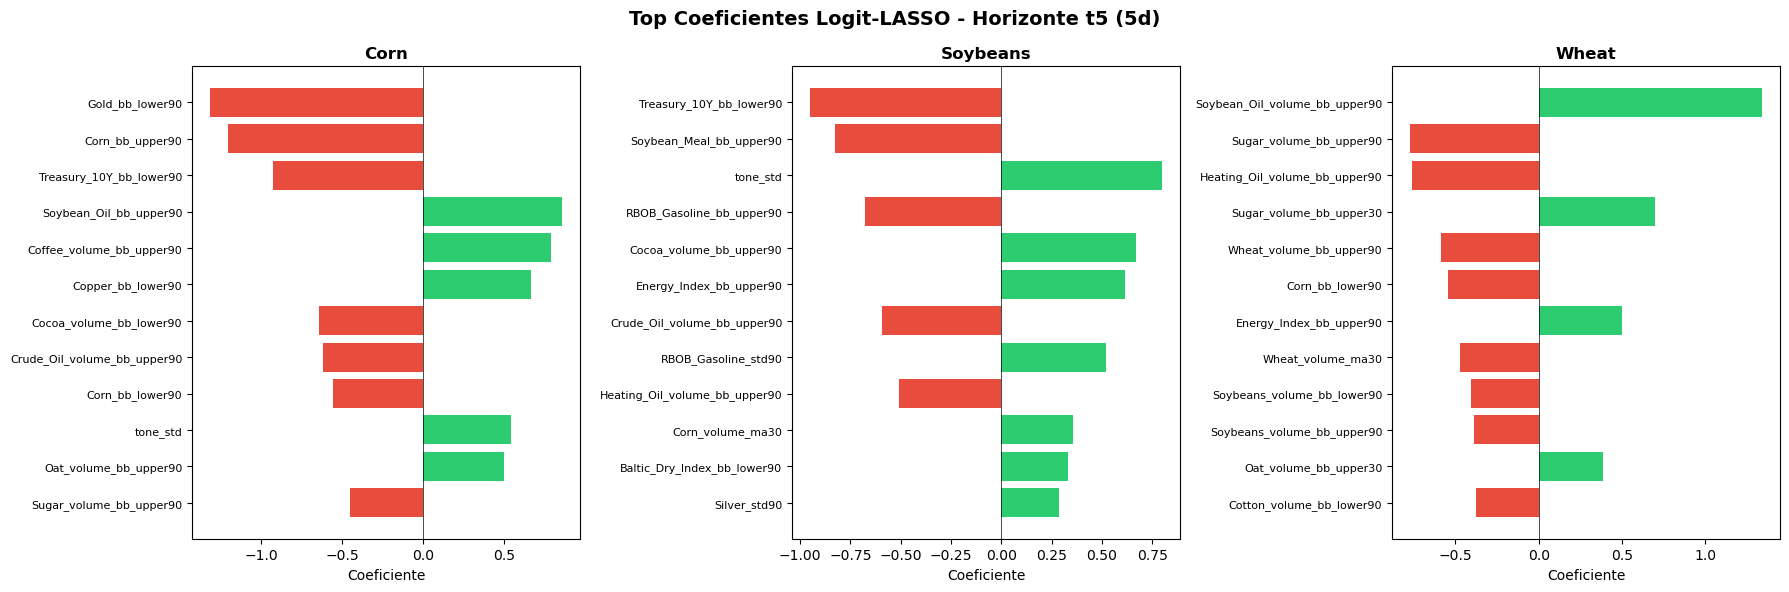

In [29]:
# Visualizar top coeficientes para horizonte t5 (1 semana)
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

horizon_focus = 't5'

for idx, commodity in enumerate(TARGET_COMMODITIES):
    ax = axes[idx]
    
    # Corregido: models[commodity][horizon_focus]
    if commodity in models and horizon_focus in models[commodity]:
        model = models[commodity][horizon_focus]
        feature_names = results[commodity][horizon_focus]['feature_names']
        top_coefs = analyze_coefficients(model, feature_names, top_n=12)
        
        if len(top_coefs) > 0:
            colors = ['#2ecc71' if c > 0 else '#e74c3c' for c in top_coefs.values]
            bars = ax.barh(range(len(top_coefs)), top_coefs.values, color=colors)
            ax.set_yticks(range(len(top_coefs)))
            ax.set_yticklabels(top_coefs.index, fontsize=8)
            ax.invert_yaxis()
            ax.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
            ax.set_xlabel('Coeficiente')
            ax.set_title(f'{commodity}', fontsize=12, fontweight='bold')
        else:
            ax.text(0.5, 0.5, 'Sin coeficientes\nno-cero', ha='center', va='center', transform=ax.transAxes)
            ax.set_title(f'{commodity}', fontsize=12, fontweight='bold')

plt.suptitle(f'Top Coeficientes Logit-LASSO - Horizonte {horizon_focus} ({HORIZONS[horizon_focus]}d)', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(BASE_DIR / 'reports' / f'logit_lasso_coefficients_{horizon_focus}.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Curvas ROC y Calibración

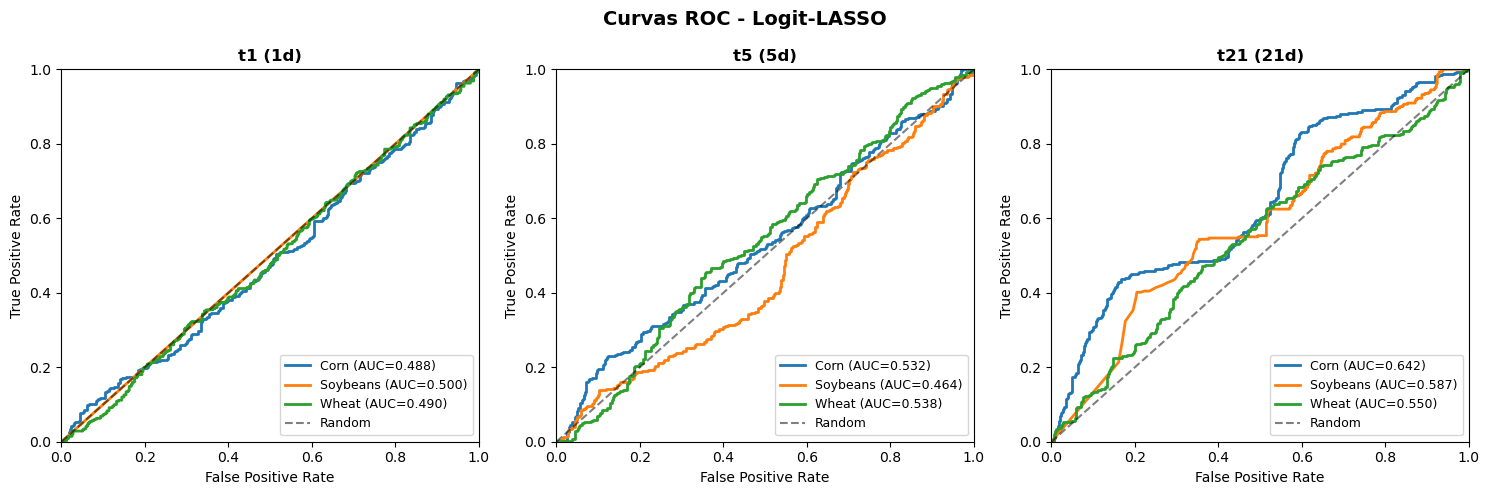

In [30]:
# Curvas ROC por horizonte
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for idx, horizon_name in enumerate(HORIZONS.keys()):
    ax = axes[idx]
    
    for commodity in TARGET_COMMODITIES:
        # Corregido: models[commodity][horizon_name]
        if commodity in models and horizon_name in models[commodity]:
            model = models[commodity][horizon_name]
            res = results[commodity][horizon_name]
            X_test = res['X_test']
            y_test = res['y_test']
            
            y_proba = model.predict_proba(X_test)[:, 1]
            fpr, tpr, _ = roc_curve(y_test, y_proba)
            auc = roc_auc_score(y_test, y_proba)
            
            ax.plot(fpr, tpr, label=f'{commodity} (AUC={auc:.3f})', linewidth=2)
    
    ax.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Random')
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.set_title(f'{horizon_name} ({HORIZONS[horizon_name]}d)', fontsize=12, fontweight='bold')
    ax.legend(loc='lower right', fontsize=9)
    ax.set_xlim([0, 1])
    ax.set_ylim([0, 1])

plt.suptitle('Curvas ROC - Logit-LASSO', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(BASE_DIR / 'reports' / 'logit_lasso_roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Walk-Forward Validation (Expanding Window)

In [31]:
from joblib import Parallel, delayed
import multiprocessing

def _train_single_period(X_train_sc, y_train, X_test_sc, y_test, dates_train_end, dates_test, C, random_state):
    """Helper para entrenar un período individual (para paralelización)."""
    # Entrenar modelo
    model = LogisticRegression(
        penalty='l1', solver='saga', C=C,
        max_iter=500,  # Reducido para velocidad
        random_state=random_state,
        class_weight='balanced',
        tol=1e-3  # Menos precisión = más rápido
    )
    model.fit(X_train_sc, y_train)
    
    # Predecir
    y_pred_proba = model.predict_proba(X_test_sc)[:, 1]
    y_pred = (y_pred_proba >= 0.5).astype(int)
    
    # Métricas
    acc = accuracy_score(y_test, y_pred)
    try:
        auc = roc_auc_score(y_test, y_pred_proba)
    except:
        auc = np.nan
    
    return {
        'train_end_date': dates_train_end,
        'test_start_date': dates_test[0],
        'test_end_date': dates_test[-1],
        'train_size': len(y_train),
        'test_size': len(y_test),
        'accuracy': acc,
        'auc': auc
    }

def walk_forward_validation_parallel(
    df, commodity, horizon_name, feature_list,
    initial_train_size=0.6,
    step_size=42,  # ~2 meses para acelerar
    C=1.0,
    n_jobs=-1  # Usar todos los cores
):
    """
    Walk-Forward Validation OPTIMIZADA con paralelización.
    
    Optimizaciones:
    - step_size mayor (42 días = ~2 meses)
    - max_iter reducido (500)
    - tolerancia relajada (1e-3)
    - Paralelización con joblib
    """
    target_col = f'{commodity}_direction_{horizon_name}'
    
    # Usar las features seleccionadas
    feature_cols = [f for f in feature_list if f in df.columns]
    
    # Preparar datos
    X = df[feature_cols].copy()
    y = df[target_col].copy()
    dates = df['date'].copy()
    
    # Solo columnas numéricas
    X = X.select_dtypes(include=[np.number])
    
    X.replace([np.inf, -np.inf], np.nan, inplace=True)
    X.fillna(X.median(), inplace=True)
    
    # Remover filas con target NaN
    valid_mask = y.notna()
    X = X[valid_mask].values  # Convertir a numpy para velocidad
    y = y[valid_mask].values
    dates = dates[valid_mask].values
    
    n = len(X)
    initial_train_idx = int(n * initial_train_size)
    
    # Preparar todos los períodos primero
    periods = []
    current_train_end = initial_train_idx
    
    while current_train_end + step_size <= n:
        test_start = current_train_end
        test_end = min(current_train_end + step_size, n)
        periods.append((current_train_end, test_start, test_end))
        current_train_end += step_size
    
    print(f"    Períodos a evaluar: {len(periods)}")
    
    # Pre-escalar todo el dataset una vez
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    # Función para procesar un período
    def process_period(period_info):
        train_end, test_start, test_end = period_info
        
        X_train_sc = X_scaled[:train_end]
        y_train = y[:train_end]
        X_test_sc = X_scaled[test_start:test_end]
        y_test = y[test_start:test_end]
        dates_test = dates[test_start:test_end]
        dates_train_end = dates[train_end-1]
        
        return _train_single_period(
            X_train_sc, y_train, X_test_sc, y_test,
            dates_train_end, dates_test, C, RANDOM_STATE
        )
    
    # Ejecutar en paralelo
    n_cores = multiprocessing.cpu_count()
    print(f"    Usando {n_cores} cores...")
    
    results = Parallel(n_jobs=n_jobs, prefer="threads")(
        delayed(process_period)(p) for p in periods
    )
    
    return pd.DataFrame(results)

In [32]:
# Ejecutar Walk-Forward OPTIMIZADO para horizonte t5
wf_results_all = {}

horizon_focus = 't5'
print(f"\n{'='*80}")
print(f"WALK-FORWARD VALIDATION (OPTIMIZADO) - Horizonte {horizon_focus}")
print(f"{'='*80}")
print("Optimizaciones aplicadas:")
print("  - Step size: 42 días (~2 meses)")
print("  - Paralelización con joblib")
print("  - max_iter=500, tol=1e-3")

import time

for commodity in TARGET_COMMODITIES:
    print(f"\n{commodity}:")
    start_time = time.time()
    
    # Obtener features seleccionadas y mejor C
    feature_list = selected_features[commodity][horizon_focus]
    best_C = results[commodity][horizon_focus]['cv_report']['best_C']
    
    wf_df = walk_forward_validation_parallel(
        df, commodity, horizon_focus, feature_list,
        initial_train_size=0.6,
        step_size=42,  # ~2 meses en vez de 21
        C=best_C,
        n_jobs=-1
    )
    
    elapsed = time.time() - start_time
    wf_results_all[commodity] = wf_df
    
    print(f"  Tiempo: {elapsed:.1f}s")
    print(f"  Períodos evaluados: {len(wf_df)}")
    print(f"  Accuracy promedio: {wf_df['accuracy'].mean():.4f} ± {wf_df['accuracy'].std():.4f}")
    print(f"  AUC promedio: {wf_df['auc'].mean():.4f} ± {wf_df['auc'].std():.4f}")


WALK-FORWARD VALIDATION (OPTIMIZADO) - Horizonte t5
Optimizaciones aplicadas:
  - Step size: 42 días (~2 meses)
  - Paralelización con joblib
  - max_iter=500, tol=1e-3

Corn:
    Períodos a evaluar: 64
    Usando 16 cores...
  Tiempo: 110.3s
  Períodos evaluados: 64
  Accuracy promedio: 0.5186 ± 0.1267
  AUC promedio: 0.5371 ± 0.1431

Soybeans:
    Períodos a evaluar: 64
    Usando 16 cores...
  Tiempo: 110.3s
  Períodos evaluados: 64
  Accuracy promedio: 0.5186 ± 0.1267
  AUC promedio: 0.5371 ± 0.1431

Soybeans:
    Períodos a evaluar: 64
    Usando 16 cores...
  Tiempo: 69.9s
  Períodos evaluados: 64
  Accuracy promedio: 0.5134 ± 0.1123
  AUC promedio: 0.5361 ± 0.1641

Wheat:
    Períodos a evaluar: 64
    Usando 16 cores...
  Tiempo: 69.9s
  Períodos evaluados: 64
  Accuracy promedio: 0.5134 ± 0.1123
  AUC promedio: 0.5361 ± 0.1641

Wheat:
    Períodos a evaluar: 64
    Usando 16 cores...
  Tiempo: 92.3s
  Períodos evaluados: 64
  Accuracy promedio: 0.5298 ± 0.1179
  AUC promedio:

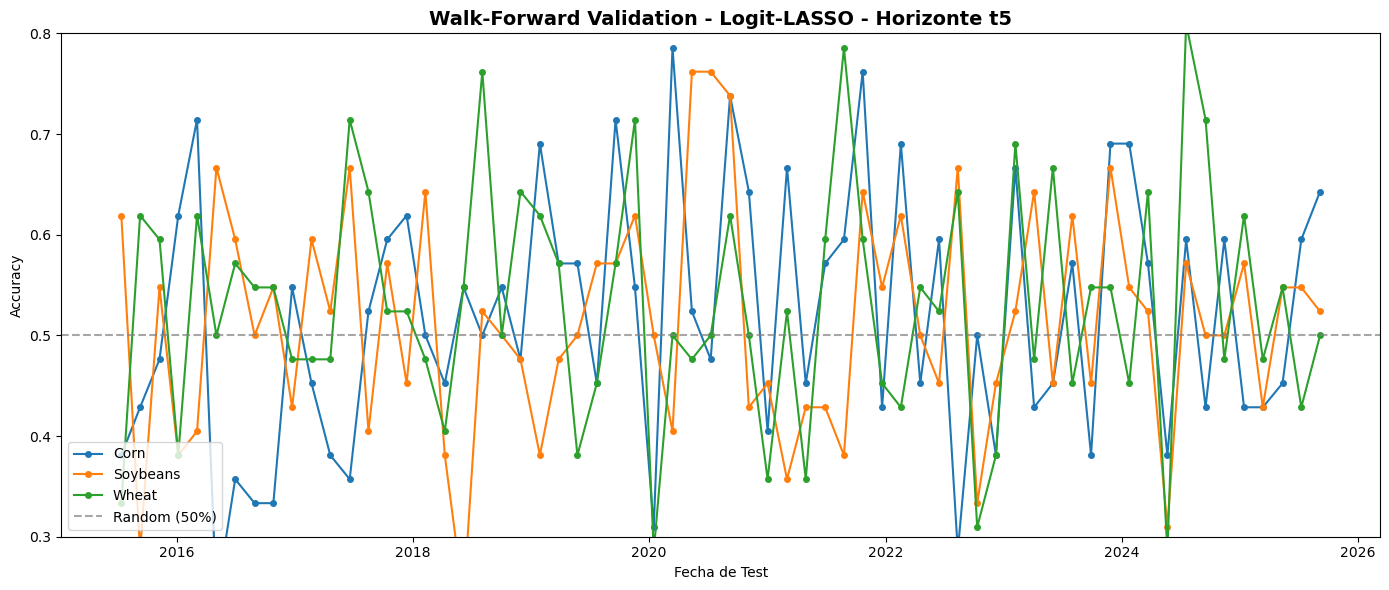

In [33]:
# Visualizar evolución temporal de Walk-Forward
fig, ax = plt.subplots(figsize=(14, 6))

for commodity in TARGET_COMMODITIES:
    wf_df = wf_results_all[commodity]
    ax.plot(wf_df['test_start_date'], wf_df['accuracy'], 
            marker='o', markersize=4, label=commodity, linewidth=1.5)

ax.axhline(y=0.5, color='gray', linestyle='--', alpha=0.7, label='Random (50%)')
ax.set_xlabel('Fecha de Test')
ax.set_ylabel('Accuracy')
ax.set_title(f'Walk-Forward Validation - Logit-LASSO - Horizonte {horizon_focus}', 
             fontsize=14, fontweight='bold')
ax.legend(loc='lower left')
ax.set_ylim([0.3, 0.8])

plt.tight_layout()
plt.savefig(BASE_DIR / 'reports' / f'walk_forward_logit_lasso_{horizon_focus}.png', dpi=150, bbox_inches='tight')
plt.show()

## 7.1 Calibración de Probabilidades (Platt Scaling)

**Fundamento:** Las probabilidades de Logistic Regression pueden estar mal calibradas. Platt Scaling ajusta las probabilidades usando validación cruzada, mejorando la confiabilidad de las predicciones sin afectar la capacidad discriminativa (AUC).

**Métrica clave:** Brier Score (menor = mejor calibración)

In [ ]:
# =============================================================================
# CALIBRACIÓN DE PROBABILIDADES - Mejora la confiabilidad de las predicciones
# =============================================================================
from sklearn.calibration import CalibratedClassifierCV

print("="*80)
print("CALIBRACIÓN DE PROBABILIDADES - Platt Scaling")
print("="*80)

calibrated_models = {}
calibration_results = {}

for commodity in TARGET_COMMODITIES:
    print(f"\n{commodity}:")
    calibrated_models[commodity] = {}
    calibration_results[commodity] = {}
    
    for horizon_name in ['t5', 't21']:  # Saltamos t1 (random)
        # Preparar datos
        feature_list = selected_features[commodity][horizon_name]
        X_train, X_test, y_train, y_test, feature_names, scaler = prepare_data(
            df, commodity, horizon_name, feature_list
        )
        
        # Obtener el mejor C del modelo ya entrenado
        best_C = results[commodity][horizon_name]['cv_report']['best_C']
        
        # Modelo base LASSO con los mejores parámetros
        base_model = LogisticRegression(
            penalty='l1',
            solver='saga',
            C=best_C,
            max_iter=3000,
            random_state=RANDOM_STATE,
            class_weight='balanced'
        )
        
        # Calibrar con Platt scaling (cv=5)
        calibrated = CalibratedClassifierCV(
            estimator=base_model,
            method='sigmoid',
            cv=5
        )
        calibrated.fit(X_train, y_train)
        
        # Probabilidades antes y después de calibración
        y_prob_uncal = results[commodity][horizon_name]['y_prob']
        y_prob_cal = calibrated.predict_proba(X_test)[:, 1]
        
        # Métricas de calibración
        brier_uncal = brier_score_loss(y_test, y_prob_uncal)
        brier_cal = brier_score_loss(y_test, y_prob_cal)
        ll_uncal = log_loss(y_test, y_prob_uncal)
        ll_cal = log_loss(y_test, y_prob_cal)
        auc_cal = roc_auc_score(y_test, y_prob_cal)
        
        # Guardar
        calibrated_models[commodity][horizon_name] = calibrated
        calibration_results[commodity][horizon_name] = {
            'brier_uncal': brier_uncal,
            'brier_cal': brier_cal,
            'logloss_uncal': ll_uncal,
            'logloss_cal': ll_cal,
            'auc_calibrated': auc_cal,
            'y_prob_calibrated': y_prob_cal
        }
        
        # Actualizar results con probabilidades calibradas
        results[commodity][horizon_name]['y_prob_calibrated'] = y_prob_cal
        results[commodity][horizon_name]['brier_calibrated'] = brier_cal
        
        delta_brier = brier_cal - brier_uncal
        print(f"  [{horizon_name}] Brier: {brier_uncal:.4f} → {brier_cal:.4f} (Δ={delta_brier:+.4f})")
        print(f"       LogLoss: {ll_uncal:.4f} → {ll_cal:.4f} | AUC (cal): {auc_cal:.4f}")

# Resumen
print("\n" + "="*60)
print("IMPACTO DE CALIBRACIÓN (promedio)")
print("="*60)
brier_improvements = []
for c in TARGET_COMMODITIES:
    for h in ['t5', 't21']:
        if h in calibration_results[c]:
            delta = calibration_results[c][h]['brier_cal'] - calibration_results[c][h]['brier_uncal']
            brier_improvements.append(delta)
            
avg_improvement = np.mean(brier_improvements)
print(f"Δ Brier Score promedio: {avg_improvement:+.4f} (menor = mejor)")
print("La calibración mejora la confiabilidad de las probabilidades predichas.")

## 8. Guardar Resultados

In [ ]:
# Guardar resultados
output_dir = PROCESSED_DIR / 'final_modeling'
output_dir.mkdir(exist_ok=True)

# Resumen de resultados
df_summary.to_csv(output_dir / 'logit_lasso_results_summary.csv', index=False)
print(f"✓ Resumen guardado: logit_lasso_results_summary.csv")

# Walk-Forward results (solo si existe)
if wf_results_all:
    for commodity in TARGET_COMMODITIES:
        if commodity in wf_results_all:
            wf_results_all[commodity].to_csv(
                output_dir / f'walk_forward_logit_lasso_{commodity.lower()}_{horizon_focus}.csv', 
                index=False
            )
    print(f"✓ Walk-Forward results guardados")
else:
    print("⚠️ Walk-Forward no ejecutado, saltando guardado")

# Metadata completa (corregido: results[commodity][horizon])
metadata = {
    'fecha_generacion': datetime.now().isoformat(),
    'modelo': 'LogisticRegression with L1 (LASSO) + Platt Scaling',
    'commodities': TARGET_COMMODITIES,
    'horizons': HORIZONS,
    'optimization': {
        'cv_method': 'TimeSeriesSplit',
        'n_splits': 5,
        'param_grid': {'C': [0.001, 0.01, 0.1, 0.5, 1.0, 5.0, 10.0, 50.0, 100.0]},
        'refit_metric': 'roc_auc'
    },
    'calibration': {
        'method': 'Platt Scaling (sigmoid)',
        'cv': 5,
        'avg_brier_improvement': float(avg_improvement) if 'avg_improvement' in dir() else None
    },
    'results': {
        c: {
            h: {
                'best_C': results[c][h]['cv_report']['best_C'],
                'n_features': results[c][h]['cv_report']['n_features_nonzero'],
                'cv_auc': results[c][h]['cv_report']['cv_scores']['roc_auc'],
                'test_metrics': results[c][h]['test_metrics'],
                'brier_calibrated': results[c][h].get('brier_calibrated', None)
            } for h in HORIZONS.keys()
        } for c in TARGET_COMMODITIES
    }
}

with open(output_dir / 'logit_lasso_metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2, default=str)

print(f"✓ Metadata guardada: logit_lasso_metadata.json")

✓ Resumen guardado: logit_lasso_results_summary.csv
✓ Walk-Forward results guardados
✓ Metadata guardada: logit_lasso_metadata.json
